In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('../Datasets/data.csv')

In [4]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [5]:
X=df.iloc[:,0:3].values
y=df.iloc[:,-1].values

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_predict=lr.predict(X_test)

In [9]:
Residual=y_test-y_predict

## 1. Relationship btw x and y must be linear

Text(0.5, 1.0, 'Feature3')

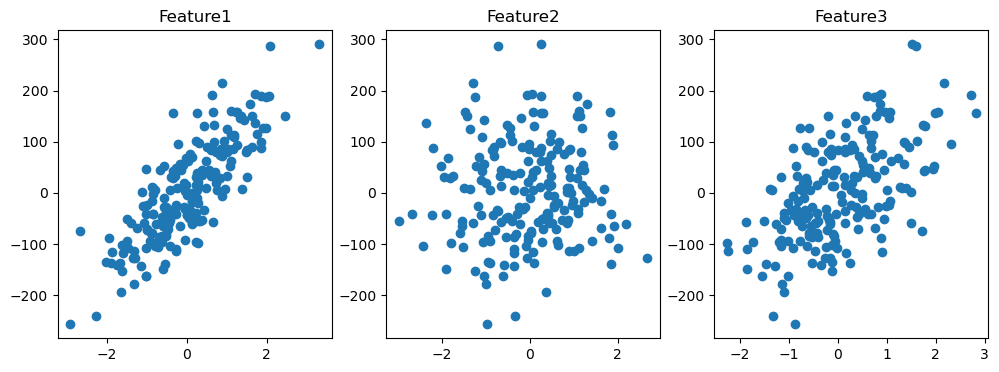

In [12]:
fig,(ax1,ax2,ax3)=plt.subplots(ncols=3,figsize=(12,4))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title('Feature1')
ax2.scatter(df['feature2'],df['target'])
ax2.set_title('Feature2')
ax3.scatter(df['feature3'],df['target'])
ax3.set_title('Feature3')


## 2. No Multicollinearity

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train,i))

In [28]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.00195,1.011273,1.011211


<Axes: >

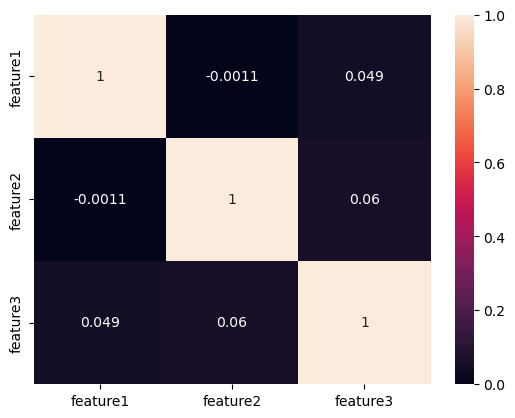

In [29]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## 3. Normality of Residual

C:\Users\anush\AppData\Local\Temp\ipykernel_29612\596208342.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Residual)


((array([-2.11583547, -1.7314906 , -1.50271646, -1.33321868, -1.19520249,
         -1.07683093, -0.97189321, -0.87669641, -0.78885043, -0.70670905,
         -0.62908229, -0.55507545, -0.48399287, -0.41527745, -0.34847074,
         -0.28318561, -0.2190868 , -0.15587657, -0.09328369, -0.03105452,
          0.03105452,  0.09328369,  0.15587657,  0.2190868 ,  0.28318561,
          0.34847074,  0.41527745,  0.48399287,  0.55507545,  0.62908229,
          0.70670905,  0.78885043,  0.87669641,  0.97189321,  1.07683093,
          1.19520249,  1.33321868,  1.50271646,  1.7314906 ,  2.11583547]),
  array([-38.29392098, -35.36080321, -32.45534286, -29.27301617,
         -27.11182967, -26.55847379, -24.62369179, -20.15944225,
         -18.98969935, -18.79615267, -18.59642181, -17.21771138,
         -15.92736716, -15.58787503, -12.94685756,  -9.13475832,
          -8.07466401,  -4.81896089,  -4.71037201,  -1.02932558,
           0.36143191,   1.76669512,   3.01891599,   3.2152343 ,
           5.501

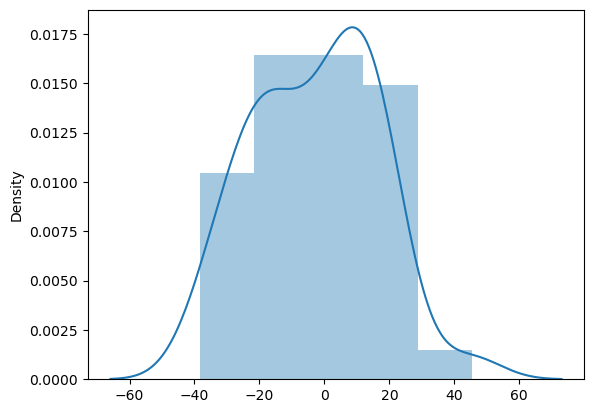

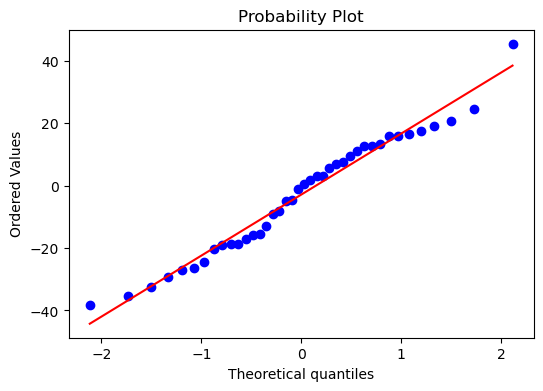

In [38]:
import scipy as sp
sns.distplot(Residual)
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(Residual,plot=ax,fit=True)

## 4. Homoscedasticity(it means when you plot your residual it should be homogenous)

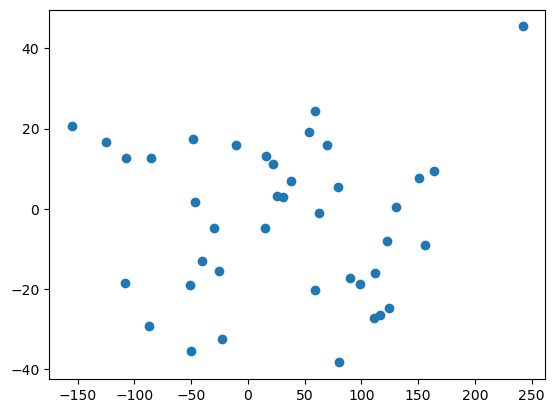

In [39]:
plt.scatter(y_predict,Residual)

## 5. No Autocorrelation

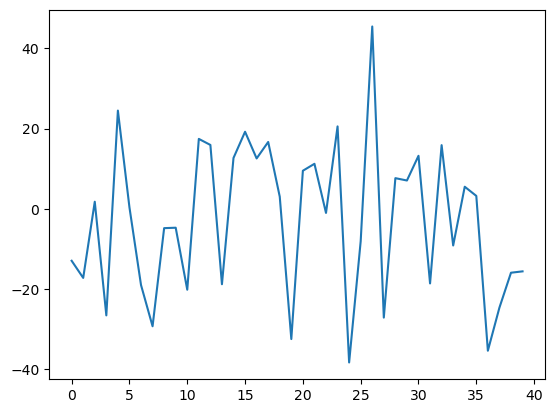

In [40]:
plt.plot(Residual)